## Importing the Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Importing dataframe

In [2]:
df_emotion=pd.read_csv('fear_greed_index.csv')
df_historical=pd.read_csv('historical_data.csv')


## PreProcessing the data and converting it into required data

In [3]:
# first fixing the date
df_historical['date'] = df_historical['Timestamp IST'].str.split(' ').str[0]
df_historical=df_historical.drop(columns=['Timestamp IST'])
df_historical['date'] = pd.to_datetime(df_historical['date'], format='%d-%m-%Y').dt.strftime('%Y-%m-%d')


In [4]:
df_historical.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02


In [5]:
summary = df_historical.groupby(['Account', 'date']).agg(
    daily_pnl_per_trader=('Closed PnL', 'sum'),
    total_trades_per_day_per_trader=('Account', 'count'),
    # Average Trade Size
    avg_trade_size=('Size USD', 'mean'),
    # Win Rate Components
    wins=('Closed PnL', lambda x: (x > 0).sum()),
    # Long/Short Ratio Components
    buy_count=('Side', lambda x: (x == 'BUY').sum()),
    sell_count=('Side', lambda x: (x == 'SELL').sum()),
).reset_index()

In [6]:
summary['win_rate']=(summary['wins']/summary['total_trades_per_day_per_trader'])*100

In [7]:
summary=summary.drop(columns=['wins'])

In [8]:
df_emotion=df_emotion.drop(columns=['timestamp','value'])

In [9]:
processedData = pd.merge(df_emotion, summary, on='date', how='inner')



In [10]:
np.shape(processedData)

(2340, 9)

In [11]:
processedData

,classification,date,Account,daily_pnl_per_trader,total_trades_per_day_per_trader,avg_trade_size,buy_count,sell_count,win_rate
0,Greed,2023-05-01,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,0.000000,3,159.000000,3,0,0.000000
1,Extreme Greed,2023-12-05,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,0.000000,9,5556.203333,7,2,0.000000
2,Greed,2023-12-14,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,-205.434737,11,10291.213636,5,6,36.363636
3,Greed,2023-12-15,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,-24.632034,2,5304.975000,2,0,0.000000
4,Greed,2023-12-16,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,0.000000,3,5116.256667,3,0,0.000000
...,...,...,...,...,...,...,...,...,...
2335,Neutral,2025-05-01,0xa0feb3725a9335f49874d7cd8eaad6be45b27416,1449.529436,288,1130.887083,187,101,35.069444
2336,Neutral,2025-05-01,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,102460.171640,73,3462.110685,57,16,78.082192
2337,Neutral,2025-05-01,0xbaaaf6571ab7d571043ff1e313a9609a10637864,1.860320,1,3.900000,0,1,100.000000
2338,Neutral,2025-05-01,0xbd5fead7180a9c139fa51a103cb6a2ce86ddb5c3,-113601.020138,116,16681.467759,76,40,0.862069


In [12]:
processedData['profit_count'] = (processedData['daily_pnl_per_trader'] > 0).astype(int)
processedData['loss_count'] = (processedData['daily_pnl_per_trader'] <= 0).astype(int)

In [13]:
processedData.to_csv('processedData.csv',index=False)

In [14]:
emotion_counts = processedData.groupby("classification")[["buy_count","sell_count"]].sum()

trade_per_day=processedData.groupby('classification')[['total_trades_per_day_per_trader']].sum()

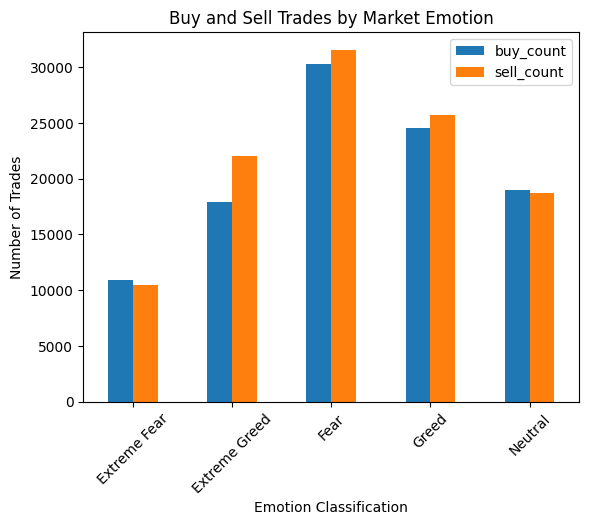

In [15]:
emotion_counts.plot(kind="bar")

plt.title("Buy and Sell Trades by Market Emotion")
plt.xlabel("Emotion Classification")
plt.ylabel("Number of Trades")
plt.xticks(rotation=45)

plt.show()

[]

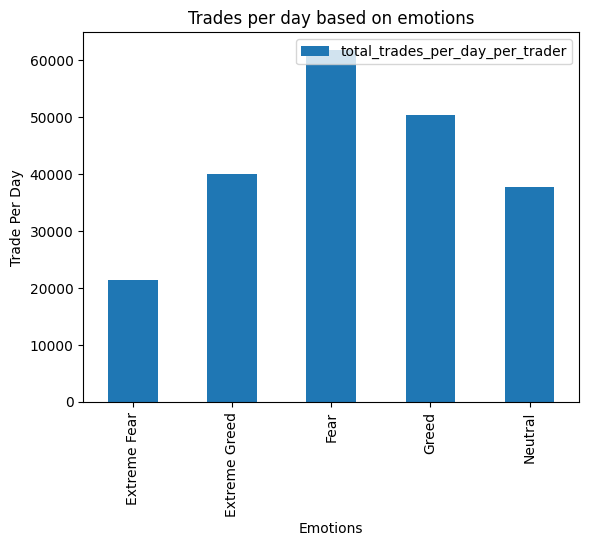

In [16]:
trade_per_day.plot(kind='bar')
plt.title("Trades per day based on emotions")
plt.xlabel('Emotions')
plt.ylabel('Trade Per Day')
plt.plot()

In [17]:
loss_profit_classification=processedData.groupby('classification')[["loss_count"]].sum()

<Axes: xlabel='classification'>

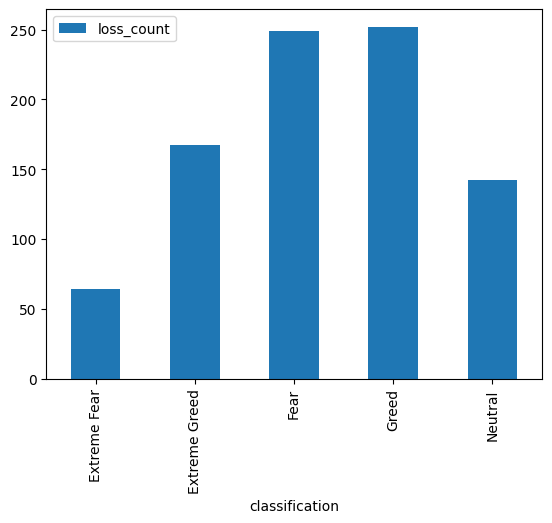

In [18]:
loss_profit_classification.plot(kind='bar')